In [196]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

In [197]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [198]:
# loading the dataset.
df = pd.read_csv('/content/Restaurant_Reviews.tsv', sep='\t')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [199]:
# shape of the datatse
print(df.shape)

(1000, 2)


In [200]:
# columns present in the dataset
print(list(df.columns))

['Review', 'Liked']


In [201]:
# checking for null values
df.isna().sum()

,0
Review,0
Liked,0


In [202]:
# checking for any duplicate values
df.duplicated().sum()

np.int64(4)

In [203]:
# removing duplicate values
df = df.drop_duplicates()
print(df.duplicated().sum())

0


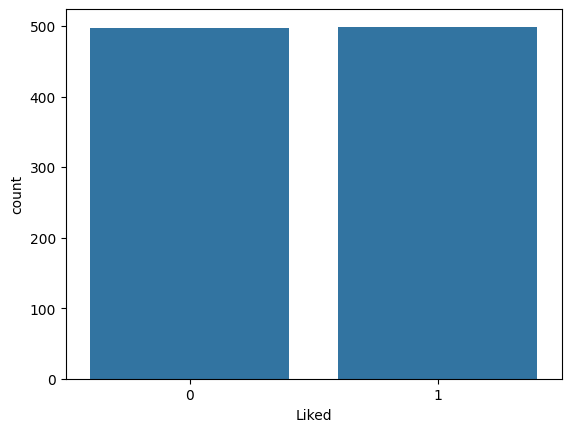

In [204]:
# checking if there is any data imbalance in target
sns.barplot(x=df['Liked'].value_counts().index, y=df['Liked'].value_counts())
plt.show()

In [205]:
# checking any ranodm review
print(df['Review'][43])

On a positive note, our server was very attentive and provided great service.


In [206]:
print(df.columns)

Index(['Review', 'Liked'], dtype='object')


In [207]:
# will perform other pre-processing steps
# Including (converting into lowercase, negation handling and removing punctuations)
import contractions
import re

def pre_process(text):
  text = text.lower().strip()
  text = re.sub('<.*?>', ' ', text)
  text = contractions.fix(text)
  text = re.sub(r'[^\w\s]', '', text)
  clean_text = re.sub(r'\s+', ' ', text).strip()

  return clean_text

In [208]:
df['cleaned_review'] = df['Review'].apply(pre_process)
print(df['cleaned_review'].head())

0                                 wow loved this place
1                                    crust is not good
2             not tasty and the texture was just nasty
3    stopped by during the late may bank holiday of...
4    the selection on the menu was great and so wer...
Name: cleaned_review, dtype: object


In [209]:
# Tokenization
df['tokens'] = df['cleaned_review'].apply(word_tokenize)
print(df['tokens'].head())

0                            [wow, loved, this, place]
1                               [crust, is, not, good]
2    [not, tasty, and, the, texture, was, just, nasty]
3    [stopped, by, during, the, late, may, bank, ho...
4    [the, selection, on, the, menu, was, great, an...
Name: tokens, dtype: object


In [210]:
print(df['tokens'][43])

['on', 'a', 'positive', 'note', 'our', 'server', 'was', 'very', 'attentive', 'and', 'provided', 'great', 'service']


In [211]:
# next step is removal of stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
negators = {'not', 'no', 'nor', 'never', 'none', 'neither'}
stop_words = stop_words - negators # keep negators out of removal list

df['stopwords_removed'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])
print(df['stopwords_removed'][43])

['positive', 'note', 'server', 'attentive', 'provided', 'great', 'service']


In [212]:
# Next step is : Lemmatization
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
nltk.download('wordnet')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [213]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback

def lemmatize_tokens(tokens):
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

df['lemmatized_words'] = df['stopwords_removed'].apply(lemmatize_tokens)
print(df['lemmatized_words'].head())

0                                   [wow, love, place]
1                                   [crust, not, good]
2                         [not, tasty, texture, nasty]
3    [stop, late, may, bank, holiday, rick, steve, ...
4                      [selection, menu, great, price]
Name: lemmatized_words, dtype: object


In [214]:
# taking one example and checking what we have done till now
print('Original:   ', df['Review'][143])
print('Cleaned:    ', df['cleaned_review'][143])
print('Tokens:     ', df['tokens'][143])
print('No stopwords:', df['stopwords_removed'][143])
print('Lemmatized: ', df['lemmatized_words'][143])

Original:    And the red curry had so much bamboo shoots and wasn't very tasty to me.
Cleaned:     and the red curry had so much bamboo shoots and was not very tasty to me
Tokens:      ['and', 'the', 'red', 'curry', 'had', 'so', 'much', 'bamboo', 'shoots', 'and', 'was', 'not', 'very', 'tasty', 'to', 'me']
No stopwords: ['red', 'curry', 'much', 'bamboo', 'shoots', 'not', 'tasty']
Lemmatized:  ['red', 'curry', 'much', 'bamboo', 'shoot', 'not', 'tasty']


In [215]:
df.head(5)

,Review,Liked,cleaned_review,tokens,stopwords_removed,lemmatized_words
0,Wow... Loved this place.,1,wow loved this place,"[wow, loved, this, place]","[wow, loved, place]","[wow, love, place]"
1,Crust is not good.,0,crust is not good,"[crust, is, not, good]","[crust, not, good]","[crust, not, good]"
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty,"[not, tasty, and, the, texture, was, just, nasty]","[not, tasty, texture, nasty]","[not, tasty, texture, nasty]"
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...,"[stopped, by, during, the, late, may, bank, ho...","[stopped, late, may, bank, holiday, rick, stev...","[stop, late, may, bank, holiday, rick, steve, ..."
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...,"[the, selection, on, the, menu, was, great, an...","[selection, menu, great, prices]","[selection, menu, great, price]"


In [216]:
# creating a new column final_text
# joining all the tokens of lemmatized_words into string and storing it in final_text
df['final_text'] = df['lemmatized_words'].apply(lambda x: ' '.join(x))
print(df['final_text'].head())

0                                       wow love place
1                                       crust not good
2                              not tasty texture nasty
3    stop late may bank holiday rick steve recommen...
4                           selection menu great price
Name: final_text, dtype: object


In [217]:
X = df['final_text']
y = df['Liked']

In [218]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
print(X_train.shape)
print(y_train.shape)

(796,)
(796,)


In [219]:
# now use TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(796, 1491)
(200, 1491)


In [220]:
# applying Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [221]:
# applying Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train,y_train)
y_pred_nb = nb.predict(X_test)

In [222]:
# Evaluation of Both
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for name, y_pred in [('Logistic Regression', y_pred_lr), ('Naive Bayes', y_pred_nb)]:
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

--- Logistic Regression ---
Accuracy: 0.835
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.84      0.83      0.83       100

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200


--- Naive Bayes ---
Accuracy: 0.785
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       100
           1       0.77      0.82      0.79       100

    accuracy                           0.79       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.79      0.78       200




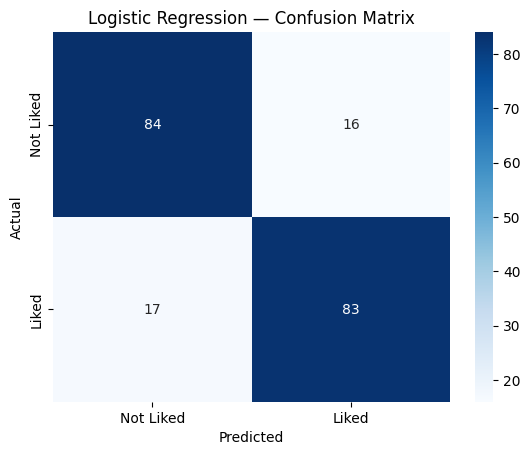

In [223]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Liked', 'Liked'],
            yticklabels=['Not Liked', 'Liked'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()